# ĐỒ ÁN KHAI PHÁ DỮ LIỆU
## Medical Appointment No Shows

### Sinh viên thực hiện
- Nguyễn Dương Bảo Trân - 3123410386
- Giang Hào Tường - 3123410421

### Bài toán trên dataset 1
Dataset này được khai phá theo **2 hướng bài toán**:

**Bài toán 1: Phân loại (Classification)**  
Dự đoán bệnh nhân có bỏ hẹn khám bệnh hay không, tức là dự đoán biến mục tiêu `No-show`.

**Bài toán 2: Phân tích kết hợp (Association Analysis)**  
Khai phá các luật kết hợp để tìm ra những tổ hợp điều kiện thường xuất hiện cùng với hành vi no-show, từ đó rút ra các mẫu dữ liệu đặc trưng.

### Hai câu hỏi khai phá dữ liệu
1. Những yếu tố nào ảnh hưởng nhiều nhất đến việc bệnh nhân không đến khám?
2. Có thể xây dựng mô hình dự đoán bệnh nhân no-show đủ tốt để hỗ trợ bệnh viện/phòng khám hay không?

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report,
    ConfusionMatrixDisplay, roc_curve
)

from mlxtend.frequent_patterns import apriori, association_rules

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

print("Đã import xong thư viện.")

Đã import xong thư viện.


### 1. Đọc dữ liệu và xem thông tin tổng quan

In [2]:
file_path = "KaggleV2-May-2016.csv"
df = pd.read_csv(file_path)

print("Kích thước dữ liệu:", df.shape)
display(df.head())
df.info()
display(df.describe(include="all").T)

Kích thước dữ liệu: (110527, 14)


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


<class 'pandas.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  str    
 3   ScheduledDay    110527 non-null  str    
 4   AppointmentDay  110527 non-null  str    
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  str    
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  str    
dtypes: float64(1), int64(8), str(5)
memory usage: 17.6 MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PatientId,110527.0,NaN,NaN,NaN,147496265710394.0625,256094920291738.875,39217.84439,4172614444192.0,31731838713978.0,94391720898175.0,999981631772427.0
AppointmentID,110527.0,NaN,NaN,NaN,5675305.123427,71295.75154,5030230.0,5640285.5,5680573.0,5725523.5,5790484.0
Gender,110527,2,F,71840,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ScheduledDay,110527,103549,2016-05-06T07:09:54Z,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AppointmentDay,110527,27,2016-06-06T00:00:00Z,4692,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,110527.0,NaN,NaN,NaN,37.088874,23.110205,-1.0,18.0,37.0,55.0,115.0
Neighbourhood,110527,81,JARDIM CAMBURI,7717,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Scholarship,110527.0,NaN,NaN,NaN,0.098266,0.297675,0.0,0.0,0.0,0.0,1.0
Hipertension,110527.0,NaN,NaN,NaN,0.197246,0.397921,0.0,0.0,0.0,0.0,1.0
Diabetes,110527.0,NaN,NaN,NaN,0.071865,0.258265,0.0,0.0,0.0,0.0,1.0


### 2. Kiểm tra dữ liệu thiếu, dữ liệu trùng lặp và phân bố biến mục tiêu ban đầu

In [3]:
missing = df.isnull().sum()
print("Các cột có giá trị thiếu:")
display(missing[missing > 0])

duplicate_count = df.duplicated().sum()
print("Số dòng trùng lặp:", duplicate_count)

if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Kích thước dữ liệu sau khi xóa trùng:", df.shape)

print("Phân bố biến No-show:")
display(df["No-show"].value_counts())
display((df["No-show"].value_counts(normalize=True) * 100).round(2))

Các cột có giá trị thiếu:


Series([], dtype: int64)

Số dòng trùng lặp: 0
Phân bố biến No-show:


No-show
No     88208
Yes    22319
Name: count, dtype: int64

No-show
No     79.81
Yes    20.19
Name: proportion, dtype: float64

### 3. Tiền xử lý dữ liệu: chuẩn hóa tên cột và chuyển kiểu dữ liệu ngày tháng

In [4]:
data = df.copy()

data.columns = [col.strip().lower().replace("-", "_").replace(" ", "_") for col in data.columns]

data["scheduledday"] = pd.to_datetime(data["scheduledday"])
data["appointmentday"] = pd.to_datetime(data["appointmentday"])

print("Tên cột sau khi chuẩn hóa:")
print(data.columns.tolist())

display(data.head())
display(data[["scheduledday", "appointmentday"]].dtypes)

Tên cột sau khi chuẩn hóa:
['patientid', 'appointmentid', 'gender', 'scheduledday', 'appointmentday', 'age', 'neighbourhood', 'scholarship', 'hipertension', 'diabetes', 'alcoholism', 'handcap', 'sms_received', 'no_show']


,patientid,appointmentid,gender,scheduledday,appointmentday,age,neighbourhood,scholarship,hipertension,diabetes,alcoholism,handcap,sms_received,no_show
0,2.987250e+13,5642903,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,1,1,0,0,0,No


scheduledday      datetime64[us, UTC]
appointmentday    datetime64[us, UTC]
dtype: object

### 4. Tạo thuộc tính mới và xử lý các giá trị bất thường

In [5]:
# Đảm bảo 2 cột ngày tháng đúng kiểu datetime
data["scheduledday"] = pd.to_datetime(data["scheduledday"], errors="coerce")
data["appointmentday"] = pd.to_datetime(data["appointmentday"], errors="coerce")

# Tính số ngày chờ: bỏ phần giờ nhưng vẫn giữ kiểu datetime của pandas
data["waiting_days"] = (
    data["appointmentday"].dt.normalize() - data["scheduledday"].dt.normalize()
).dt.days

data["scheduled_weekday"] = data["scheduledday"].dt.day_name()
data["appointment_weekday"] = data["appointmentday"].dt.day_name()
data["scheduled_hour"] = data["scheduledday"].dt.hour

print("Số tuổi âm:", (data["age"] < 0).sum())
print("Số waiting_days âm:", (data["waiting_days"] < 0).sum())

data = data[(data["age"] >= 0) & (data["waiting_days"] >= 0)].copy()

data["target"] = data["no_show"].map({"Yes": 1, "No": 0})

# Rút trích đặc trưng phục vụ khai phá dữ liệu
data["age_group"] = pd.cut(
    data["age"],
    bins=[-1, 14, 24, 44, 64, 120],
    labels=["0-14", "15-24", "25-44", "45-64", "65+"]
)

data["waiting_group"] = pd.cut(
    data["waiting_days"],
    bins=[-1, 0, 3, 7, 14, 10**9],
    labels=["0 day", "1-3 days", "4-7 days", "8-14 days", ">14 days"]
)

chronic_cols = ["hipertension", "diabetes", "alcoholism", "handcap"]
data["chronic_count"] = data[chronic_cols].sum(axis=1)

print("Kích thước dữ liệu sau khi làm sạch:", data.shape)
display(data[["age", "age_group", "waiting_days", "waiting_group", "chronic_count", "target"]].head())

Số tuổi âm: 1
Số waiting_days âm: 5
Kích thước dữ liệu sau khi làm sạch: (110521, 22)


,age,age_group,waiting_days,waiting_group,chronic_count,target
0,62,45-64,0,0 day,1,0
1,56,45-64,0,0 day,0,0
2,62,45-64,0,0 day,0,0
3,8,0-14,0,0 day,0,0
4,56,45-64,0,0 day,2,0


### 5. Loại bỏ các cột không cần thiết cho mô hình

In [6]:
drop_cols = ["patientid", "appointmentid", "no_show"]
data_model = data.drop(columns=drop_cols)

print("Kích thước dữ liệu sau khi loại bỏ cột:", data_model.shape)
display(data_model.head())

Kích thước dữ liệu sau khi loại bỏ cột: (110521, 19)


,gender,scheduledday,appointmentday,age,neighbourhood,scholarship,hipertension,diabetes,alcoholism,handcap,sms_received,waiting_days,scheduled_weekday,appointment_weekday,scheduled_hour,target,age_group,waiting_group,chronic_count
0,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,0,0,0,0,Friday,Friday,18,0,45-64,0 day,1
1,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,0,0,0,0,Friday,Friday,16,0,45-64,0 day,0
2,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0,0,0,0,0,Friday,Friday,16,0,45-64,0 day,0
3,F,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,0,0,0,0,0,0,0,Friday,Friday,17,0,0-14,0 day,0
4,F,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,1,1,0,0,0,0,Friday,Friday,16,0,45-64,0 day,2


### 5.1. Mô tả chất lượng dữ liệu và mức độ mất cân bằng lớp

,dtype,n_unique,missing,missing_pct
scheduledday,"datetime64[us, UTC]",103543,0,0.0
waiting_days,int64,129,0,0.0
age,int64,103,0,0.0
neighbourhood,str,81,0,0.0
appointmentday,"datetime64[us, UTC]",27,0,0.0
scheduled_hour,int32,16,0,0.0
scheduled_weekday,str,6,0,0.0
appointment_weekday,str,6,0,0.0
chronic_count,int64,6,0,0.0
handcap,int64,5,0,0.0


Tỷ lệ lớp mục tiêu:


Show       79.81
No-show    20.19
Name: proportion, dtype: float64

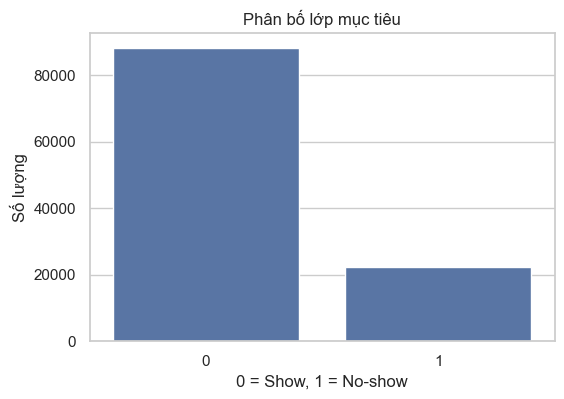

In [7]:
quality_df = pd.DataFrame({
    "dtype": data_model.dtypes.astype(str),
    "n_unique": data_model.nunique(),
    "missing": data_model.isnull().sum(),
    "missing_pct": (data_model.isnull().mean() * 100).round(2)
}).sort_values(by=["missing", "n_unique"], ascending=[False, False])

display(quality_df)

print("Tỷ lệ lớp mục tiêu:")
target_dist = (data["target"].value_counts(normalize=True) * 100).round(2)
target_dist.index = ["Show" if i == 0 else "No-show" for i in target_dist.index]
display(target_dist)

plt.figure(figsize=(6, 4))
sns.countplot(x="target", data=data)
plt.title("Phân bố lớp mục tiêu")
plt.xlabel("0 = Show, 1 = No-show")
plt.ylabel("Số lượng")
plt.show()

### 6. Thống kê mô tả sau tiền xử lý

In [8]:
display(data_model.describe().T)

summary_stats = data[["age", "waiting_days", "chronic_count"]].agg(
    ["mean", "median", "std", "min", "max"]
).T
display(summary_stats)

print("Tỷ lệ no-show:")
display((data["target"].value_counts(normalize=True) * 100).round(2))

,count,mean,std,min,25%,50%,75%,max
age,110521.0,37.089386,23.109885,0.0,18.0,37.0,55.0,115.0
scholarship,110521.0,0.098271,0.297682,0.0,0.0,0.0,0.0,1.0
hipertension,110521.0,0.197257,0.397929,0.0,0.0,0.0,0.0,1.0
diabetes,110521.0,0.071869,0.258272,0.0,0.0,0.0,0.0,1.0
alcoholism,110521.0,0.030401,0.171690,0.0,0.0,0.0,0.0,1.0
handcap,110521.0,0.022231,0.161494,0.0,0.0,0.0,0.0,4.0
sms_received,110521.0,0.321043,0.466879,0.0,0.0,0.0,1.0,1.0
waiting_days,110521.0,10.184345,15.255153,0.0,0.0,4.0,15.0,179.0
scheduled_hour,110521.0,10.774522,3.216204,6.0,8.0,10.0,13.0,21.0
target,110521.0,0.201898,0.401419,0.0,0.0,0.0,0.0,1.0


,mean,median,std,min,max
age,37.089386,37.0,23.109885,0.0,115.0
waiting_days,10.184345,4.0,15.255153,0.0,179.0
chronic_count,0.321758,0.0,0.631389,0.0,5.0


Tỷ lệ no-show:


target
0    79.81
1    20.19
Name: proportion, dtype: float64

### 7. Phân tích đơn biến

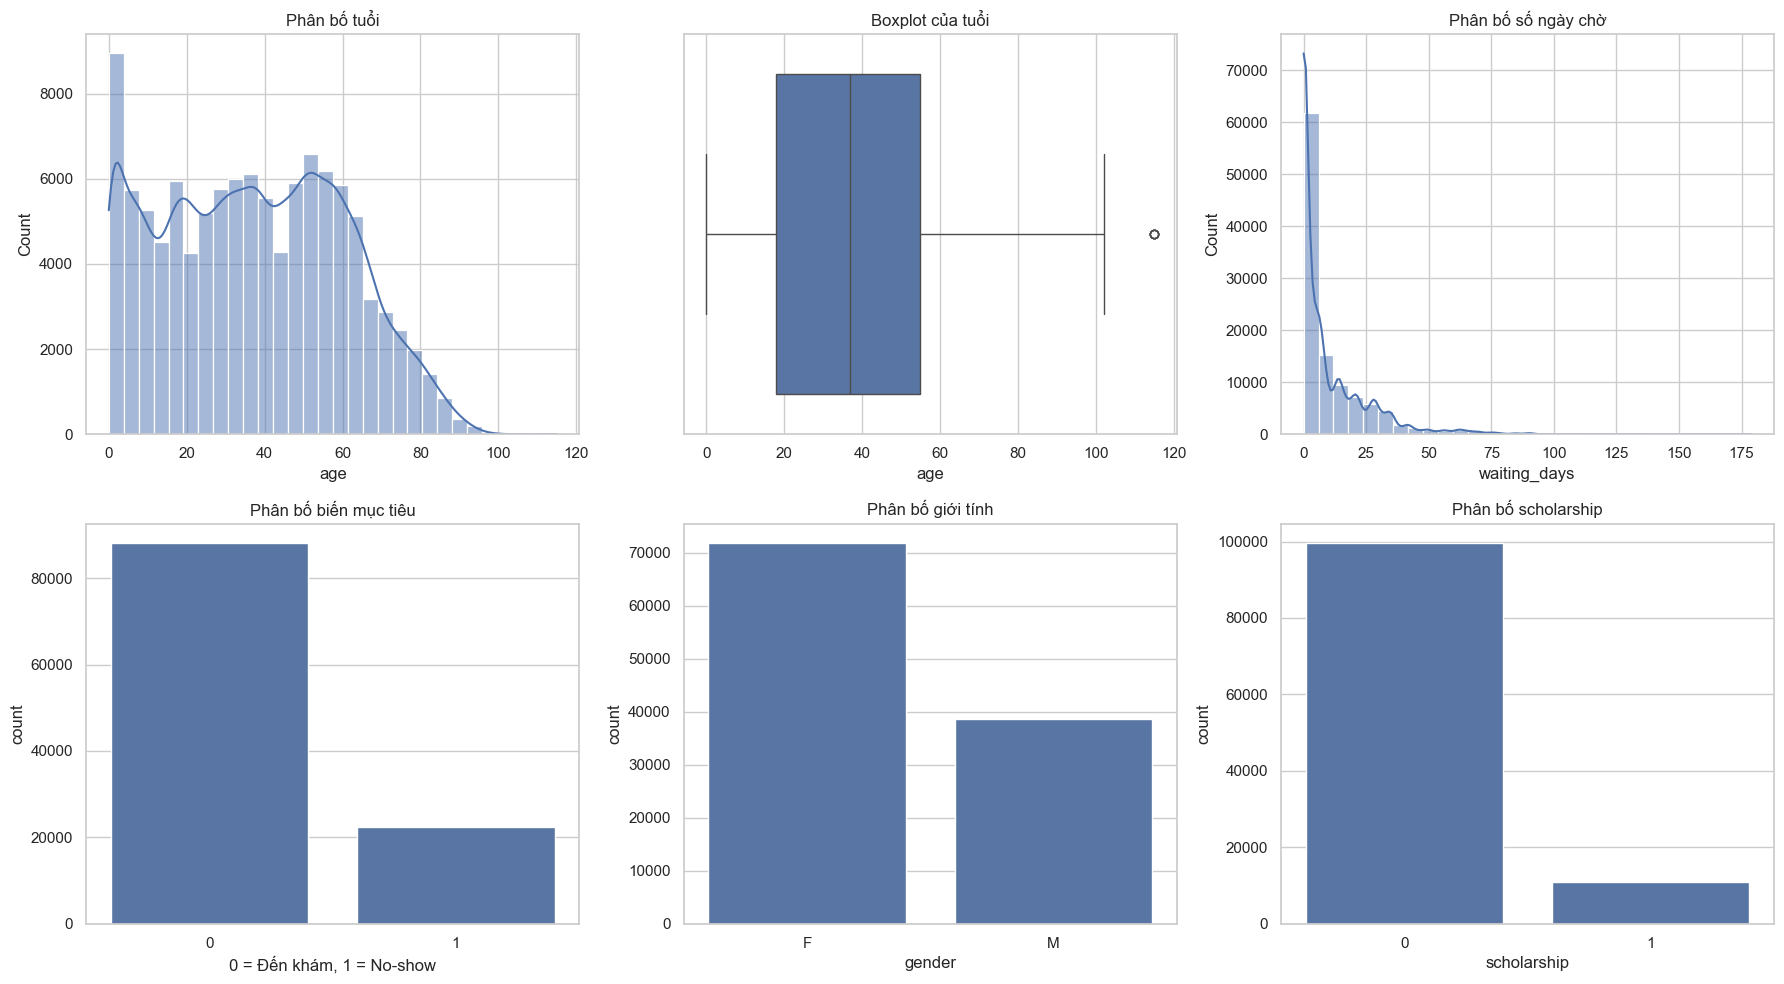

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sns.histplot(data["age"], bins=30, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Phân bố tuổi")

sns.boxplot(x=data["age"], ax=axes[0, 1])
axes[0, 1].set_title("Boxplot của tuổi")

sns.histplot(data["waiting_days"], bins=30, kde=True, ax=axes[0, 2])
axes[0, 2].set_title("Phân bố số ngày chờ")

sns.countplot(x="target", data=data, ax=axes[1, 0])
axes[1, 0].set_title("Phân bố biến mục tiêu")
axes[1, 0].set_xlabel("0 = Đến khám, 1 = No-show")

sns.countplot(x="gender", data=data, ax=axes[1, 1])
axes[1, 1].set_title("Phân bố giới tính")

sns.countplot(x="scholarship", data=data, ax=axes[1, 2])
axes[1, 2].set_title("Phân bố scholarship")

plt.tight_layout()
plt.show()

### 7.1. Phân tích ngoại lai và giá trị bất thường

age: 5 giá trị ngoại lai theo IQR, ngưỡng [-37.50, 110.50]
waiting_days: 5803 giá trị ngoại lai theo IQR, ngưỡng [-22.50, 37.50]


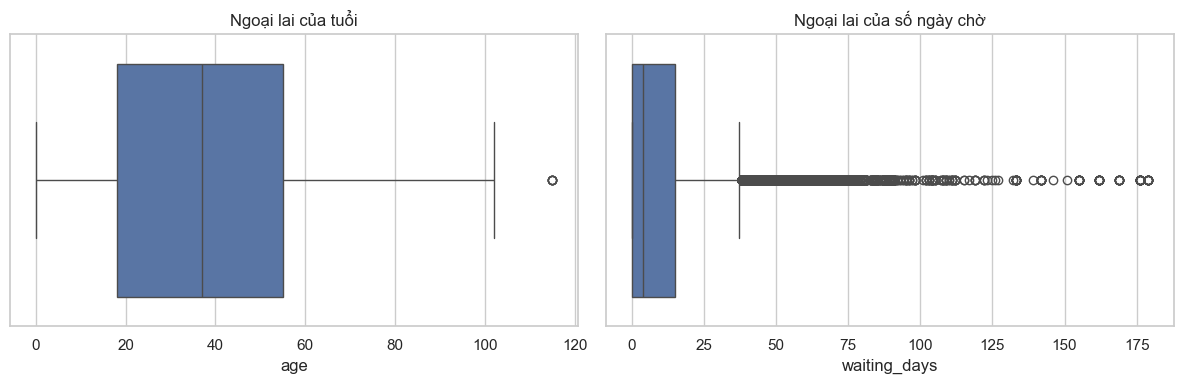

In [10]:
def iqr_outlier_count(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((series < lower) | (series > upper)).sum()
    return count, lower, upper

for col in ["age", "waiting_days"]:
    count, lower, upper = iqr_outlier_count(data[col])
    print(f"{col}: {count} giá trị ngoại lai theo IQR, ngưỡng [{lower:.2f}, {upper:.2f}]")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=data["age"], ax=axes[0])
axes[0].set_title("Ngoại lai của tuổi")
sns.boxplot(x=data["waiting_days"], ax=axes[1])
axes[1].set_title("Ngoại lai của số ngày chờ")
plt.tight_layout()
plt.show()

### 8. Phân tích đa biến

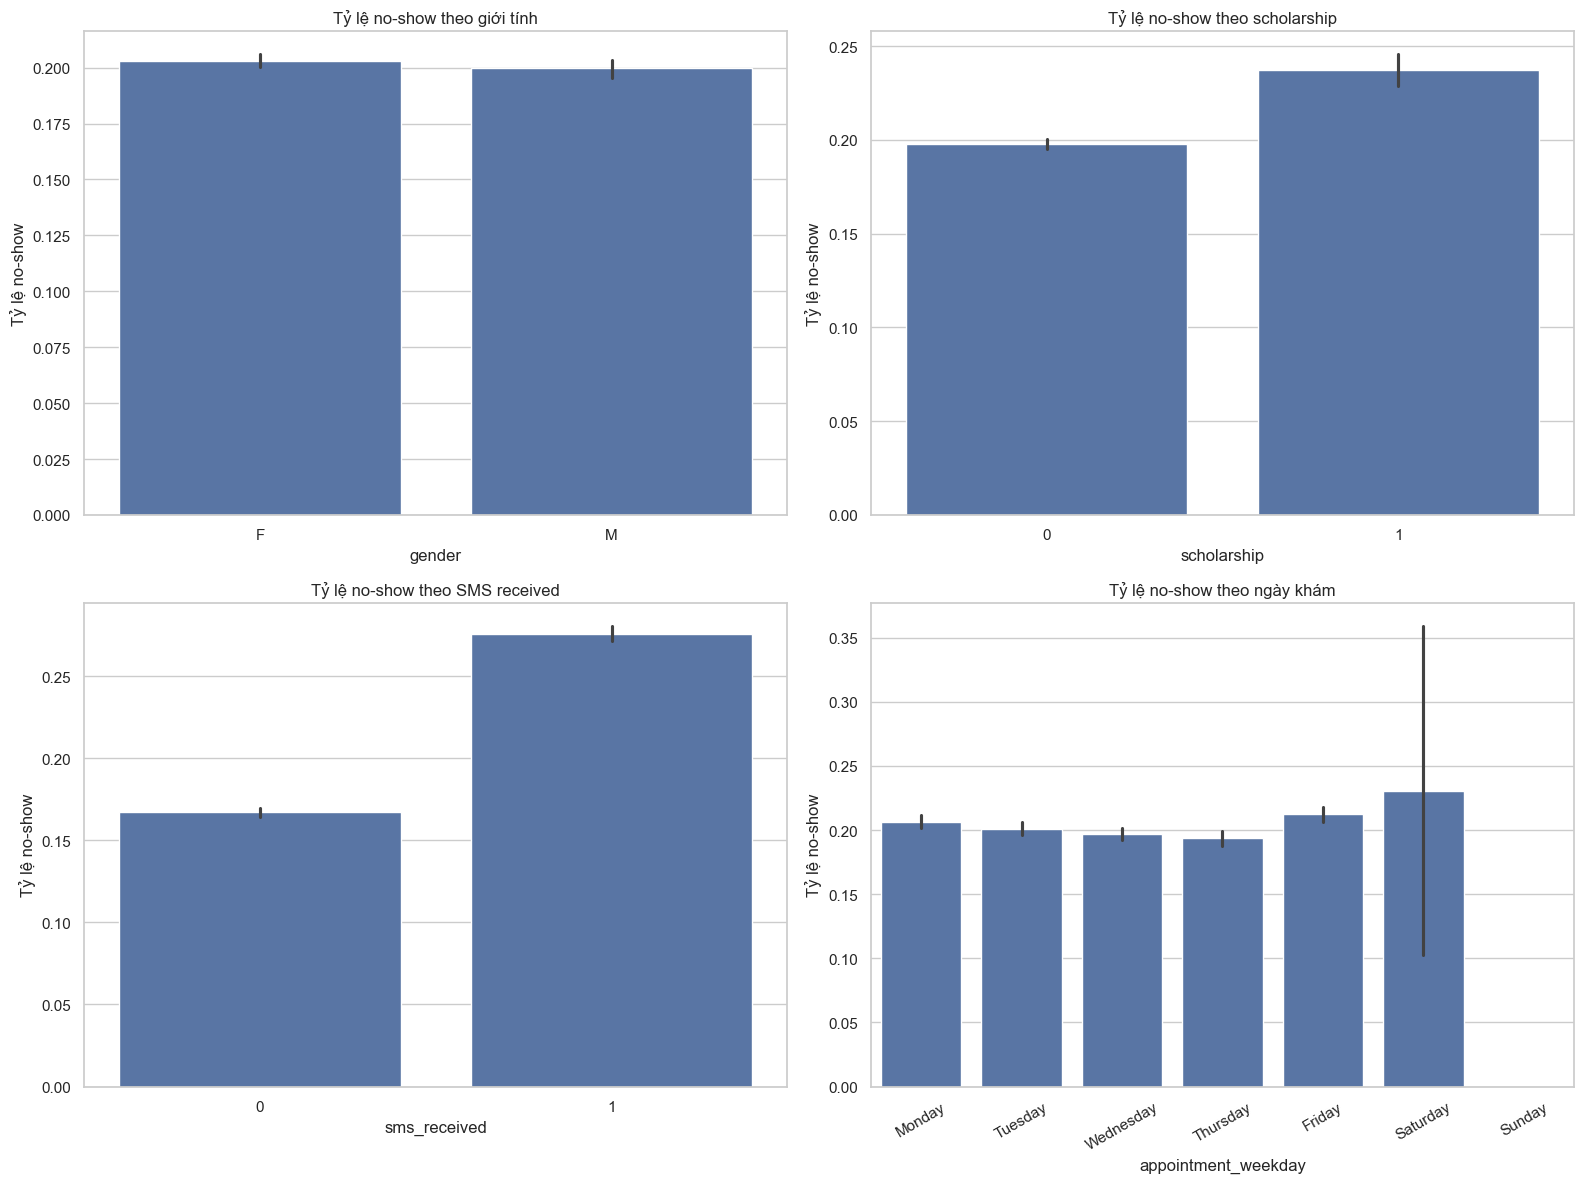

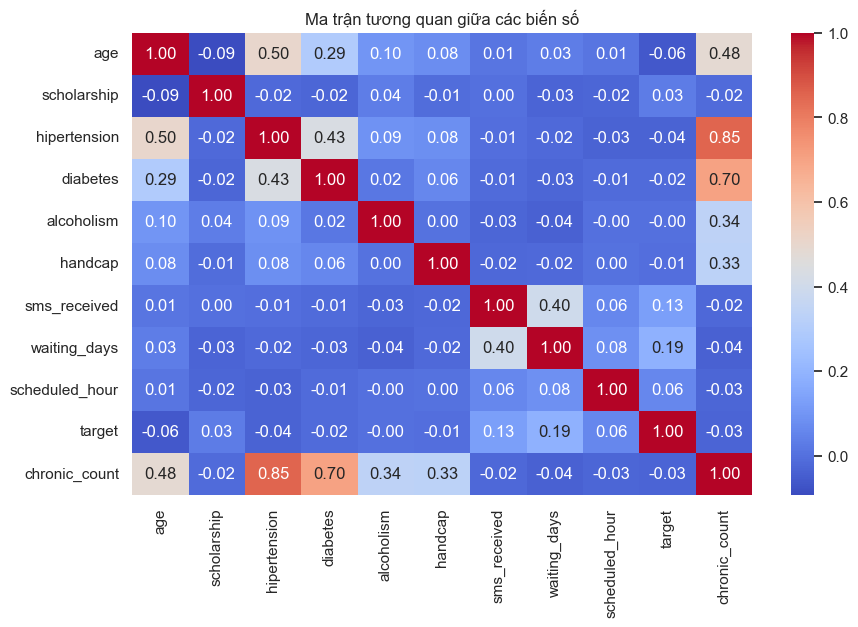

In [11]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.barplot(x="gender", y="target", data=data, ax=axes[0, 0])
axes[0, 0].set_title("Tỷ lệ no-show theo giới tính")
axes[0, 0].set_ylabel("Tỷ lệ no-show")

sns.barplot(x="scholarship", y="target", data=data, ax=axes[0, 1])
axes[0, 1].set_title("Tỷ lệ no-show theo scholarship")
axes[0, 1].set_ylabel("Tỷ lệ no-show")

sns.barplot(x="sms_received", y="target", data=data, ax=axes[1, 0])
axes[1, 0].set_title("Tỷ lệ no-show theo SMS received")
axes[1, 0].set_ylabel("Tỷ lệ no-show")

sns.barplot(x="appointment_weekday", y="target", data=data, order=weekday_order, ax=axes[1, 1])
axes[1, 1].set_title("Tỷ lệ no-show theo ngày khám")
axes[1, 1].set_ylabel("Tỷ lệ no-show")
axes[1, 1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

numeric_cols = data_model.select_dtypes(include=np.number).columns

plt.figure(figsize=(10, 6))
sns.heatmap(data_model[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Ma trận tương quan giữa các biến số")
plt.show()

### 8.1. Phân tích tỷ lệ no-show theo nhóm tuổi và nhóm thời gian chờ

age_group
0-14     21.18
15-24    25.26
25-44    22.38
45-64    17.20
65+      15.50
Name: No-show rate (%), dtype: float64

waiting_group
0 day         4.65
1-3 days     22.89
4-7 days     25.20
8-14 days    30.47
>14 days     32.74
Name: No-show rate (%), dtype: float64

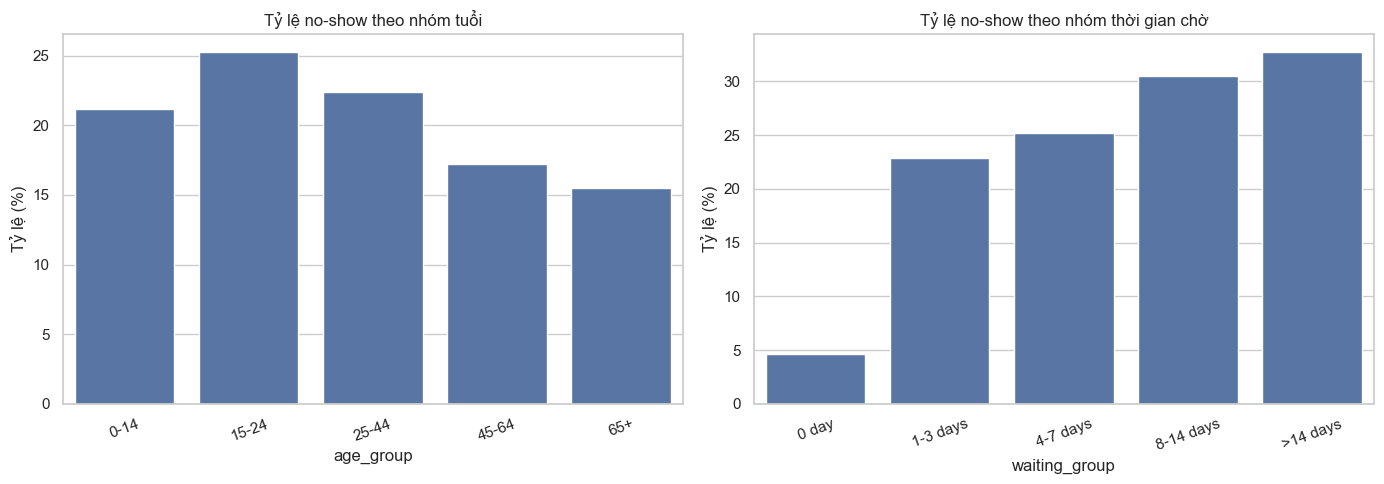

In [12]:
age_group_rate = (data.groupby("age_group")["target"].mean() * 100).round(2)
waiting_group_rate = (data.groupby("waiting_group")["target"].mean() * 100).round(2)

display(age_group_rate.rename("No-show rate (%)"))
display(waiting_group_rate.rename("No-show rate (%)"))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=age_group_rate.index, y=age_group_rate.values, ax=axes[0])
axes[0].set_title("Tỷ lệ no-show theo nhóm tuổi")
axes[0].set_ylabel("Tỷ lệ (%)")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(x=waiting_group_rate.index, y=waiting_group_rate.values, ax=axes[1])
axes[1].set_title("Tỷ lệ no-show theo nhóm thời gian chờ")
axes[1].set_ylabel("Tỷ lệ (%)")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

### 8.2. Phân tích tỷ lệ no-show theo khu vực khám bệnh

neighbourhood
ITARARÉ              26.27
JESUS DE NAZARETH    24.40
CENTRO               21.09
MARIA ORTIZ          21.00
RESISTÊNCIA          20.43
BONFIM               19.83
JARDIM CAMBURI       18.98
TABUAZEIRO           18.27
JARDIM DA PENHA      16.28
SANTA MARTHA         15.84
Name: No-show rate (%), dtype: float64

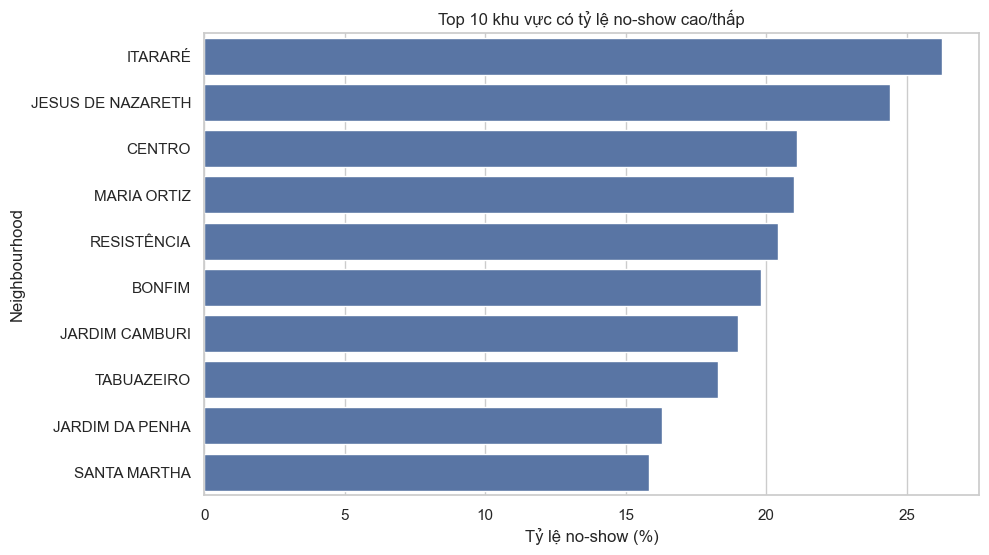

In [13]:
top_neighbourhoods = data["neighbourhood"].value_counts().head(10).index

neigh_rate = (
    data[data["neighbourhood"].isin(top_neighbourhoods)]
    .groupby("neighbourhood")["target"]
    .mean()
    .sort_values(ascending=False) * 100
).round(2)

display(neigh_rate.rename("No-show rate (%)"))

plt.figure(figsize=(10, 6))
sns.barplot(x=neigh_rate.values, y=neigh_rate.index)
plt.title("Top 10 khu vực có tỷ lệ no-show cao/thấp")
plt.xlabel("Tỷ lệ no-show (%)")
plt.ylabel("Neighbourhood")
plt.show()

### 8.3. Phân tích tổ hợp yếu tố ảnh hưởng đến no-show

sms_received,0,1
waiting_group,,
0 day,4.65,NaN
1-3 days,22.99,21.30
4-7 days,27.11,23.97
8-14 days,33.76,28.11
>14 days,37.11,29.95


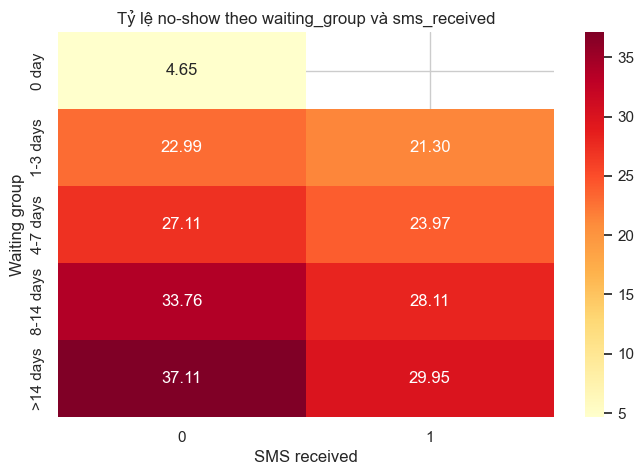

In [14]:
pivot_sms_wait = pd.crosstab(
    data["waiting_group"],
    data["sms_received"],
    values=data["target"],
    aggfunc="mean"
) * 100

display(pivot_sms_wait.round(2))

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_sms_wait, annot=True, fmt=".2f", cmap="YlOrRd")
plt.title("Tỷ lệ no-show theo waiting_group và sms_received")
plt.xlabel("SMS received")
plt.ylabel("Waiting group")
plt.show()

## Bài toán 2: Phân tích kết hợp các điều kiện liên quan đến no-show
### 8.4. Khai phá luật kết hợp từ dữ liệu lịch hẹn

In [15]:
rule_data = data[[
    "age_group", "waiting_group", "scholarship", "sms_received",
    "hipertension", "diabetes", "alcoholism", "handcap",
    "appointment_weekday", "target"
]].copy()

rule_data["scholarship"] = rule_data["scholarship"].map({1: "scholarship_yes", 0: "scholarship_no"})
rule_data["sms_received"] = rule_data["sms_received"].map({1: "sms_yes", 0: "sms_no"})
rule_data["hipertension"] = rule_data["hipertension"].map({1: "hipertension_yes", 0: "hipertension_no"})
rule_data["diabetes"] = rule_data["diabetes"].map({1: "diabetes_yes", 0: "diabetes_no"})
rule_data["alcoholism"] = rule_data["alcoholism"].map({1: "alcoholism_yes", 0: "alcoholism_no"})
rule_data["handcap"] = rule_data["handcap"].astype(str).map(lambda x: f"handcap_{x}")
rule_data["target"] = rule_data["target"].map({1: "target_noshow", 0: "target_show"})

basket = pd.get_dummies(rule_data.astype(str))

freq_items = apriori(basket, min_support=0.01, use_colnames=True)
rules = association_rules(freq_items, metric="confidence", min_threshold=0.35)

rules["antecedents_str"] = rules["antecedents"].apply(lambda x: ", ".join(sorted(list(x))))
rules["consequents_str"] = rules["consequents"].apply(lambda x: ", ".join(sorted(list(x))))

noshow_rules = rules[
    rules["consequents_str"].str.contains("target_noshow", na=False)
].sort_values(by=["lift", "confidence", "support"], ascending=False)

display(
    noshow_rules[["antecedents_str", "consequents_str", "support", "confidence", "lift"]]
    .head(10)
)

,antecedents_str,consequents_str,support,confidence,lift
163569,"age_group_15-24, waiting_group_>14 days","alcoholism_alcoholism_no, diabetes_diabetes_no...",0.012486,0.394511,2.477373
163562,"age_group_15-24, handcap_handcap_0, waiting_gr...","alcoholism_alcoholism_no, diabetes_diabetes_no...",0.012486,0.398383,2.469003
78334,"age_group_15-24, waiting_group_>14 days","alcoholism_alcoholism_no, diabetes_diabetes_no...",0.012550,0.396512,2.457407
78410,"age_group_15-24, waiting_group_>14 days","alcoholism_alcoholism_no, handcap_handcap_0, h...",0.012541,0.396226,2.450139
163560,"age_group_15-24, diabetes_diabetes_no, waiting...","alcoholism_alcoholism_no, handcap_handcap_0, h...",0.012486,0.395983,2.448633
78403,"age_group_15-24, handcap_handcap_0, waiting_gr...","alcoholism_alcoholism_no, hipertension_hiperte...",0.012541,0.400115,2.441944
163544,"age_group_15-24, diabetes_diabetes_no, handcap...","alcoholism_alcoholism_no, hipertension_hiperte...",0.012486,0.399884,2.440532
78372,"age_group_15-24, waiting_group_>14 days","diabetes_diabetes_no, handcap_handcap_0, hiper...",0.012568,0.397084,2.435953
163564,"age_group_15-24, alcoholism_alcoholism_no, wai...","diabetes_diabetes_no, handcap_handcap_0, hiper...",0.012486,0.396780,2.434086
24760,"age_group_15-24, waiting_group_>14 days","alcoholism_alcoholism_no, hipertension_hiperte...",0.012604,0.398228,2.430422


### Nhận xét về luật kết hợp

Kết quả khai phá luật kết hợp cho thấy một số tổ hợp điều kiện xuất hiện cùng nhau với xác suất no-show cao hơn mức trung bình của toàn bộ dữ liệu.  
Đáng chú ý, các luật mạnh chủ yếu liên quan đến **nhóm tuổi 15–24** và **thời gian chờ dài (>14 ngày)**, cho thấy đây là một mẫu hành vi đáng quan tâm trong dữ liệu lịch hẹn khám bệnh.

## Bài toán 1: Phân loại bệnh nhân no-show
### 9. Chuẩn bị dữ liệu cho mô hình

In [16]:
X = data_model.drop(columns=["target", "scheduledday", "appointmentday"])
y = data_model["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Kích thước X_train:", X_train.shape)
print("Kích thước X_test :", X_test.shape)
print("Biến số:", numeric_features)
print("Biến phân loại:", categorical_features)

print("\nPhân bố target trong train:")
display((y_train.value_counts(normalize=True) * 100).round(2))

print("Phân bố target trong test:")
display((y_test.value_counts(normalize=True) * 100).round(2))

Kích thước X_train: (88416, 16)
Kích thước X_test : (22105, 16)
Biến số: ['age', 'scholarship', 'hipertension', 'diabetes', 'alcoholism', 'handcap', 'sms_received', 'waiting_days', 'scheduled_hour', 'chronic_count']
Biến phân loại: ['gender', 'neighbourhood', 'scheduled_weekday', 'appointment_weekday', 'age_group', 'waiting_group']

Phân bố target trong train:


target
0    79.81
1    20.19
Name: proportion, dtype: float64

Phân bố target trong test:


target
0    79.81
1    20.19
Name: proportion, dtype: float64

### 10. Khởi tạo các mô hình phân loại

In [17]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight="balanced"
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        max_depth=5,
        class_weight="balanced"
    ),
    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_estimators=200,
        max_depth=8,
        class_weight="balanced_subsample"
    )
}

def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])
    
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    if hasattr(pipe.named_steps["classifier"], "predict_proba"):
        y_prob = pipe.predict_proba(X_test)[:, 1]
    else:
        y_prob = None
    
    result = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan
    }
    
    return pipe, y_pred, y_prob, result

print("Đã khởi tạo xong các mô hình.")

Đã khởi tạo xong các mô hình.


### 11. Huấn luyện và so sánh các mô hình

In [18]:
trained_models = {}
results = []

for name, model in models.items():
    pipe, y_pred, y_prob, result = evaluate_model(name, model, X_train, X_test, y_train, y_test)
    trained_models[name] = {
        "pipeline": pipe,
        "y_pred": y_pred,
        "y_prob": y_prob
    }
    results.append(result)

results_df = pd.DataFrame(results).sort_values(by="F1-score", ascending=False).reset_index(drop=True)
display(results_df)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.585705,0.304749,0.820972,0.444498,0.722659
1,Decision Tree,0.565981,0.297913,0.847412,0.440844,0.716450
2,Random Forest,0.548880,0.293840,0.879677,0.440530,0.725594


### Nhận xét về kết quả mô hình

Mặc dù Accuracy của ba mô hình không chênh lệch quá lớn, Logistic Regression cho **F1-score** cao nhất và đạt **Recall rất cao** đối với lớp no-show.  
Điều này phù hợp với mục tiêu của bài toán là ưu tiên phát hiện các bệnh nhân có nguy cơ bỏ hẹn, thay vì chỉ tối đa hóa Accuracy tổng thể.

### 12. Chọn mô hình tốt nhất và đánh giá chi tiết

Mô hình tốt nhất: Logistic Regression

              precision    recall  f1-score   support

           0       0.92      0.53      0.67     17642
           1       0.30      0.82      0.44      4463

    accuracy                           0.59     22105
   macro avg       0.61      0.67      0.56     22105
weighted avg       0.80      0.59      0.62     22105



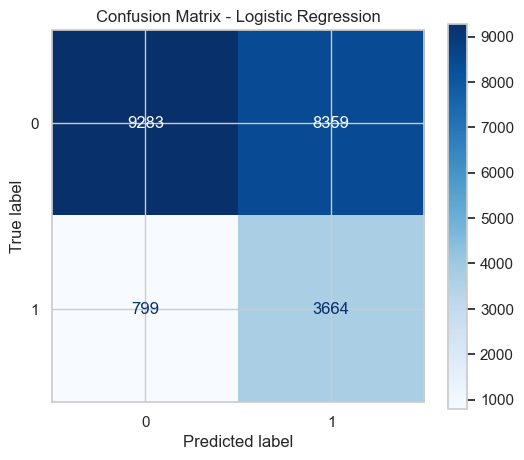

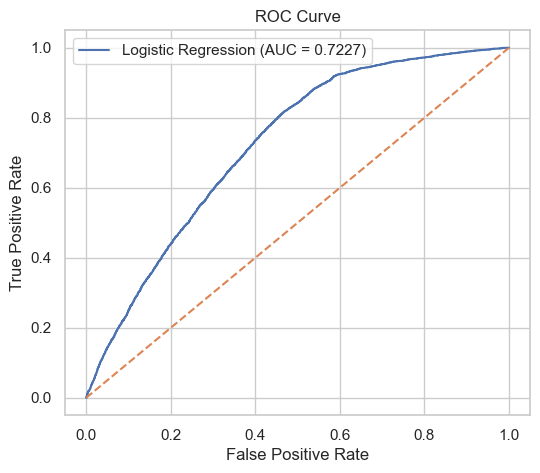

In [19]:
best_model_name = results_df.loc[0, "Model"]
best_model = trained_models[best_model_name]["pipeline"]
best_pred = trained_models[best_model_name]["y_pred"]
best_prob = trained_models[best_model_name]["y_prob"]

print("Mô hình tốt nhất:", best_model_name)
print()
print(classification_report(y_test, best_pred, zero_division=0))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, best_pred, ax=ax, cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

if best_prob is not None:
    fpr, tpr, _ = roc_curve(y_test, best_prob)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"{best_model_name} (AUC = {roc_auc_score(y_test, best_prob):.4f})")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

### 12.1. Phân tích các trường hợp dự đoán sai

In [20]:
error_df = X_test.copy()
error_df["actual"] = y_test.values
error_df["pred"] = best_pred

if best_prob is not None:
    error_df["prob_noshow"] = best_prob

false_negative = error_df[(error_df["actual"] == 1) & (error_df["pred"] == 0)]
false_positive = error_df[(error_df["actual"] == 0) & (error_df["pred"] == 1)]

print("Số False Negative (thực tế no-show nhưng dự đoán show):", len(false_negative))
print("Số False Positive (thực tế show nhưng dự đoán no-show):", len(false_positive))

print("\nPhân bố False Negative theo waiting_group:")
display(false_negative["waiting_group"].value_counts(dropna=False))

print("\nPhân bố False Negative theo age_group:")
display(false_negative["age_group"].value_counts(dropna=False))

display(false_negative.head(10))

Số False Negative (thực tế no-show nhưng dự đoán show): 799
Số False Positive (thực tế show nhưng dự đoán no-show): 8359

Phân bố False Negative theo waiting_group:


waiting_group
0 day        361
1-3 days     207
4-7 days     169
>14 days      42
8-14 days     20
Name: count, dtype: int64


Phân bố False Negative theo age_group:


age_group
45-64    318
65+      192
0-14     134
25-44     89
15-24     66
Name: count, dtype: int64

,gender,age,neighbourhood,scholarship,hipertension,diabetes,alcoholism,handcap,sms_received,waiting_days,scheduled_weekday,appointment_weekday,scheduled_hour,age_group,waiting_group,chronic_count,actual,pred,prob_noshow
18764,M,8,CRUZAMENTO,0,0,0,0,0,0,0,Wednesday,Wednesday,7,0-14,0 day,0,1,0,0.160570
85075,F,50,CRUZAMENTO,0,1,1,0,0,0,1,Tuesday,Wednesday,9,45-64,1-3 days,2,1,0,0.476059
13962,M,66,BELA VISTA,0,1,0,0,0,0,2,Monday,Wednesday,7,65+,1-3 days,1,1,0,0.456272
58214,M,80,JARDIM DA PENHA,0,1,0,0,1,0,8,Tuesday,Wednesday,8,65+,8-14 days,2,1,0,0.498612
61462,F,28,SÃO BENEDITO,0,0,0,0,0,0,0,Tuesday,Tuesday,8,25-44,0 day,0,1,0,0.156752
13179,F,50,MONTE BELO,0,0,0,0,0,1,48,Thursday,Wednesday,9,45-64,>14 days,0,1,0,0.477778
26064,F,68,SANTO ANTÔNIO,0,1,1,0,0,0,2,Tuesday,Thursday,8,65+,1-3 days,2,1,0,0.432001
37564,F,52,CARATOÍRA,0,1,0,0,0,0,0,Tuesday,Tuesday,7,45-64,0 day,1,1,0,0.125036
46675,M,82,GRANDE VITÓRIA,0,1,0,0,0,1,5,Thursday,Tuesday,11,65+,4-7 days,1,1,0,0.452898
41535,F,54,JARDIM CAMBURI,0,0,0,0,0,0,2,Monday,Wednesday,12,45-64,1-3 days,0,1,0,0.461639


### 13. Phân tích mức độ ảnh hưởng của các thuộc tính

,Feature,Coefficient
110,waiting_group_0 day,-1.797419
114,waiting_group_>14 days,0.708221
113,waiting_group_8-14 days,0.571909
82,neighbourhood_SANTOS DUMONT,0.540965
85,neighbourhood_SOLON BORGES,-0.458112
28,neighbourhood_DE LOURDES,-0.355859
106,age_group_15-24,0.354875
112,waiting_group_4-7 days,0.347704
109,age_group_65+,-0.337235
29,neighbourhood_DO CABRAL,-0.323917


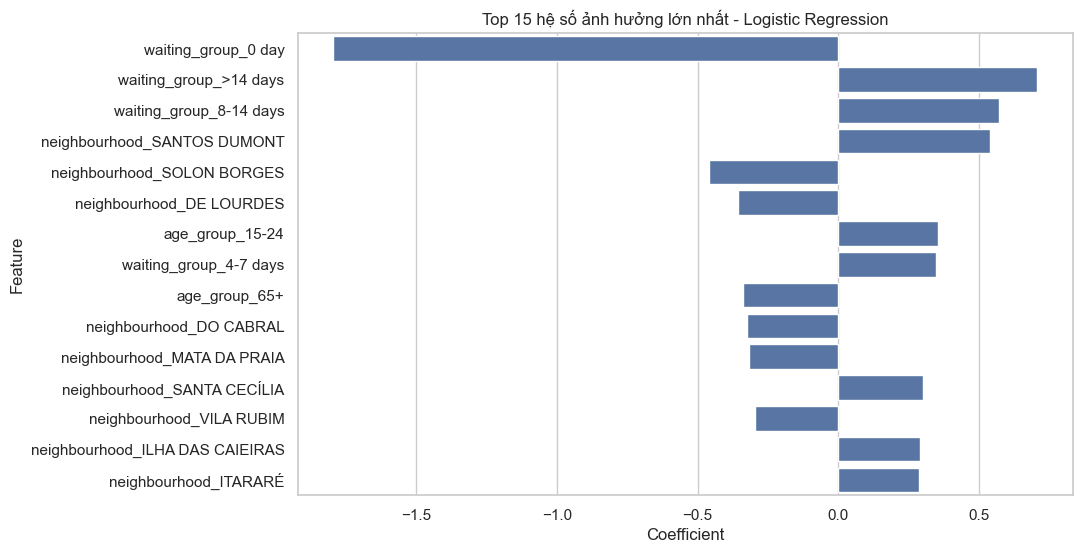

In [21]:
if best_model_name in ["Random Forest", "Decision Tree"]:
    ohe = best_model.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
    cat_feature_names = ohe.get_feature_names_out(categorical_features)
    all_feature_names = numeric_features + list(cat_feature_names)

    importances = best_model.named_steps["classifier"].feature_importances_
    feat_imp = pd.DataFrame({
        "Feature": all_feature_names,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False)

    display(feat_imp.head(15))

    plt.figure(figsize=(10, 6))
    sns.barplot(data=feat_imp.head(15), x="Importance", y="Feature")
    plt.title(f"Top 15 thuộc tính quan trọng nhất - {best_model_name}")
    plt.show()

elif best_model_name == "Logistic Regression":
    ohe = best_model.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
    cat_feature_names = ohe.get_feature_names_out(categorical_features)
    all_feature_names = numeric_features + list(cat_feature_names)

    coef = best_model.named_steps["classifier"].coef_[0]
    coef_df = pd.DataFrame({
        "Feature": all_feature_names,
        "Coefficient": coef
    }).sort_values(by="Coefficient", key=np.abs, ascending=False)

    display(coef_df.head(15))

    plt.figure(figsize=(10, 6))
    sns.barplot(data=coef_df.head(15), x="Coefficient", y="Feature")
    plt.title("Top 15 hệ số ảnh hưởng lớn nhất - Logistic Regression")
    plt.show()

### 14. Trả lời câu hỏi khai phá dữ liệu và tổng hợp các bài toán trên dataset 1

**Câu hỏi 1: Những yếu tố nào ảnh hưởng nhiều nhất đến việc bệnh nhân không đến khám?**  
Dựa trên kết quả phân tích đơn biến, đa biến, phân tích theo nhóm và mức độ ảnh hưởng của các thuộc tính trong mô hình Logistic Regression, có thể thấy hiện tượng no-show chịu tác động bởi nhiều yếu tố kết hợp.  
Trong đó, các yếu tố nổi bật nhất gồm **thời gian chờ (`waiting_group`)**, **nhóm tuổi (`age_group`)** và **khu vực khám bệnh (`neighbourhood`)**.  
Cụ thể, các nhóm có thời gian chờ dài như **`>14 days`** và **`8-14 days`** có xu hướng làm tăng khả năng no-show, trong khi nhóm **`0 day`** có xu hướng làm giảm khả năng no-show. Ngoài ra, một số khu vực khám bệnh và nhóm tuổi như **15–24** cũng có ảnh hưởng đáng kể đến hành vi bỏ hẹn.

**Câu hỏi 2: Có thể xây dựng mô hình dự đoán bệnh nhân no-show đủ tốt để hỗ trợ bệnh viện/phòng khám hay không?**  
Dựa trên kết quả thực nghiệm, mô hình tốt nhất hiện tại là **Logistic Regression** với các chỉ số:
- Accuracy = **0.585705**
- Precision = **0.304749**
- Recall = **0.820972**
- F1-score = **0.444498**
- ROC-AUC = **0.722659**

Kết quả này cho thấy mô hình có khả năng phát hiện khá tốt các trường hợp bệnh nhân no-show, thể hiện qua chỉ số **Recall cao (0.820972)**. Tuy nhiên, **Precision còn thấp**, nghĩa là mô hình vẫn dự đoán nhầm khá nhiều trường hợp show thành no-show.  
Vì vậy, có thể kết luận rằng bài toán dự đoán bệnh nhân no-show là **khả thi**, và mô hình hiện tại có thể hỗ trợ bước đầu cho bệnh viện/phòng khám trong việc nhận diện bệnh nhân có nguy cơ bỏ hẹn. Tuy nhiên, mô hình vẫn cần được cải thiện thêm để giảm số lượng cảnh báo sai.

**Tổng hợp các bài toán đã thực hiện trên dataset 1**  
Trên bộ dữ liệu Medical Appointment No Shows, đề tài đã khai thác theo **hai hướng bài toán chính**:

**Bài toán 1: Phân loại (Classification)**  
Xây dựng mô hình dự đoán bệnh nhân có bỏ hẹn khám bệnh hay không, trong đó mô hình Logistic Regression cho kết quả phù hợp nhất trong thực nghiệm hiện tại.

**Bài toán 2: Phân tích kết hợp (Association Analysis)**  
Khai phá luật kết hợp từ dữ liệu lịch hẹn để tìm ra các tổ hợp điều kiện thường xuất hiện cùng với hành vi no-show. Kết quả cho thấy hành vi bỏ hẹn không phụ thuộc vào một yếu tố đơn lẻ mà thường gắn với sự kết hợp giữa **nhóm tuổi**, **thời gian chờ** và một số **đặc điểm lịch hẹn**.

**Kết luận chung cho dataset 1**  
Như vậy, dataset 1 không chỉ được sử dụng cho **bài toán phân loại** nhằm dự đoán bệnh nhân no-show, mà còn được khai phá theo hướng **phân tích kết hợp** để rút ra các quy luật và mẫu hành vi đặc trưng liên quan đến no-show.

In [22]:
results_df.to_csv("medical_model_comparison_results.csv", index=False)
print("Đã lưu file medical_model_comparison_results.csv")
results_df

Đã lưu file medical_model_comparison_results.csv


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.585705,0.304749,0.820972,0.444498,0.722659
1,Decision Tree,0.565981,0.297913,0.847412,0.440844,0.716450
2,Random Forest,0.548880,0.293840,0.879677,0.440530,0.725594


### 15. Kết luận tạm thời

Notebook này không chỉ dừng ở việc xây dựng mô hình học máy, mà còn tập trung vào quá trình khai phá dữ liệu từ bộ dữ liệu lịch hẹn khám bệnh.  
Các bước thực hiện bao gồm: kiểm tra chất lượng dữ liệu, tiền xử lý, rút trích đặc trưng, phân tích thống kê mô tả, phân tích đơn biến, phân tích đa biến, phân tích theo nhóm, khai phá luật kết hợp và xây dựng mô hình phân loại.

Từ các bước trên, có thể rút ra một số tri thức quan trọng:
- hiện tượng no-show có liên quan rõ đến thời gian chờ giữa ngày đặt lịch và ngày khám;
- một số nhóm tuổi và khu vực khám bệnh có tỷ lệ no-show khác biệt đáng kể;
- dữ liệu cho thấy các trường hợp bệnh nhân thuộc nhóm tuổi trẻ và có thời gian chờ dài xuất hiện nhiều hơn trong các mẫu có nguy cơ no-show;
- phần khai phá luật kết hợp cũng cho thấy một số tổ hợp điều kiện lặp lại cùng với no-show, đặc biệt liên quan đến nhóm tuổi và thời gian chờ;
- mô hình Logistic Regression cho Recall cao, phù hợp với mục tiêu phát hiện bệnh nhân có nguy cơ bỏ hẹn, dù Precision còn thấp.

Kết quả này là cơ sở để tiếp tục hoàn thiện báo cáo cuối kỳ theo hướng khai phá dữ liệu và ứng dụng thực tế trong quản lý lịch khám bệnh.